#TASK 1: Data Collection & Dataset Understanding

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("="*70)
print("TASK 1: DATA COLLECTION & DATASET UNDERSTANDING")
print("="*70)


TASK 1: DATA COLLECTION & DATASET UNDERSTANDING


In [2]:
# Load the dataset
df = pd.read_csv('/content/healthy_diet_calorie_intake.csv')

print("\n Dataset loaded successfully!")
print(f" Dataset shape: {df.shape[0]} rows × {df.shape[1]} columns")



 Dataset loaded successfully!
 Dataset shape: 6000 rows × 15 columns


In [3]:
print("\n" + "="*50)
print(" FIRST 5 ROWS")
print("="*50)
print(df.head())

print("\n" + "="*50)
print("2 LAST 5 ROWS")
print("="*50)
print(df.tail())

print("\n" + "="*50)
print(" COLUMN INFORMATION")
print("="*50)
print("\nColumn Names and Data Types:")
print(df.dtypes)

print("\n" + "="*50)
print(" DATASET DESCRIPTION (Statistical Summary)")
print("="*50)
print(df.describe())

print("\n" + "="*50)
print(" MISSING VALUES CHECK")
print("="*50)
missing_values = df.isnull().sum()
print(f"Total missing values: {missing_values.sum()}")
print(missing_values[missing_values > 0] if any(missing_values > 0) else "✅ No missing values found!")

print("\n" + "="*50)
print("UNIQUE VALUES IN CATEGORICAL COLUMNS")
print("="*50)
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    print(f"\n {col}:")
    print(f"   Unique values: {df[col].nunique()}")
    print(f"   Values: {df[col].unique().tolist()}")
    print(f"   Value counts:")
    print(df[col].value_counts().head())

print("\n" + "="*50)
print(" BASIC STATISTICS SUMMARY")
print("="*50)

print("\n Numerical Columns Statistics:")
numerical_cols = df.select_dtypes(include=[np.number]).columns
for col in numerical_cols:
    print(f"\n {col}:")
    print(f"   Min: {df[col].min():.2f} | Max: {df[col].max():.2f}")
    print(f"   Mean: {df[col].mean():.2f} | Median: {df[col].median():.2f}")
    print(f"   Std Dev: {df[col].std():.2f}")

print("\n" + "="*50)
print("DATASET INFORMATION SUMMARY")
print("="*50)



 FIRST 5 ROWS
  Person_ID  Age  Gender  Height_cm  Weight_kg   BMI     Activity_Level  \
0     P0001   50    Male      176.4       74.8  24.0        Very Active   
1     P0002   18  Female      167.6       75.5  26.9          Sedentary   
2     P0003   68  Female      161.9       87.2  33.3     Lightly Active   
3     P0004   22  Female      169.3       66.9  23.3  Moderately Active   
4     P0005   30    Male      179.1       75.3  23.5          Sedentary   

   Daily_Calorie_Requirement  Daily_Calorie_Consumed  Protein_Intake_g  \
0                       2852                    2625             183.0   
1                       1904                    2044              90.1   
2                       2009                    2540             222.7   
3                       2318                    2096              69.5   
4                       2144                    1937              32.9   

   Carbohydrate_Intake_g  Fat_Intake_g  Water_Intake_Liters     Diet_Type  \
0           

#TASK 2: Data Cleaning & Preprocessing

In [4]:
# ============================================
# TASK 2: DATA CLEANING & PREPROCESSING
# Healthy Diet & Calorie Intake Dataset
# ============================================

print("\n" + "="*70)
print("TASK 2: DATA CLEANING & PREPROCESSING")
print("="*70)

# Reload dataset for clean start
df = pd.read_csv('healthy_diet_calorie_intake.csv')
print(f"\n Original dataset shape: {df.shape}")

# ---------- 1. CHECK FOR MISSING VALUES ----------
print("\n" + "-"*50)
print(" HANDLING MISSING VALUES")
print("-"*50)

print("\nBefore cleaning - Missing values:")
print(df.isnull().sum())

# No missing values in this dataset (confirmed)
print("\n No missing values found in the dataset!")

# ---------- 2. CHECK FOR DUPLICATES ----------
print("\n" + "-"*50)
print(" REMOVING DUPLICATES")
print("-"*50)

duplicates_before = df.duplicated().sum()
print(f"Duplicate rows before cleaning: {duplicates_before}")

if duplicates_before > 0:
    df.drop_duplicates(inplace=True)
    print(f" Removed {duplicates_before} duplicate rows")
else:
    print(" No duplicate rows found!")

print(f"Dataset shape after duplicate check: {df.shape}")

# ---------- 3. CHECK FOR INVALID VALUES ----------
print("\n" + "-"*50)
print(" CHECKING FOR INVALID VALUES")
print("-"*50)

# Check for negative values in columns that should be positive
positive_columns = ['Age', 'Height_cm', 'Weight_kg', 'BMI', 'Daily_Calorie_Requirement',
                     'Daily_Calorie_Consumed', 'Protein_Intake_g', 'Carbohydrate_Intake_g',
                     'Fat_Intake_g', 'Water_Intake_Liters']

print("\nChecking for negative values:")
for col in positive_columns:
    negative_count = (df[col] < 0).sum()
    if negative_count > 0:
        print(f" {col}: {negative_count} negative values found")
    else:
        print(f" {col}: No negative values")

# Fix any negative Carbohydrate values (some appear with -ve values - data error)
negative_carbs = df[df['Carbohydrate_Intake_g'] < 0]
if len(negative_carbs) > 0:
    print(f"\n Found {len(negative_carbs)} rows with negative Carbohydrate values")
    print("   Setting negative Carbohydrate values to 0")
    df.loc[df['Carbohydrate_Intake_g'] < 0, 'Carbohydrate_Intake_g'] = 0

# ---------- 4. DATA TYPE CONVERSION ----------
print("\n" + "-"*50)
print(" DATA TYPE CONVERSION")
print("-"*50)

print("\nOriginal data types:")
print(df.dtypes)

# Convert categorical columns to category type
categorical_cols = ['Gender', 'Activity_Level', 'Diet_Type', 'Health_Status']
for col in categorical_cols:
    df[col] = df[col].astype('category')
    print(f" Converted '{col}' to category type")

# ---------- 5. CREATE NEW FEATURES ----------
print("\n" + "-"*50)
print(" FEATURE ENGINEERING")
print("-"*50)

# Calculate Calorie Surplus/Deficit
df['Calorie_Difference'] = df['Daily_Calorie_Consumed'] - df['Daily_Calorie_Requirement']
df['Calorie_Status'] = df['Calorie_Difference'].apply(
    lambda x: 'Surplus' if x > 0 else ('Deficit' if x < 0 else 'Maintenance')
)

# Calculate Total Macronutrients
df['Total_Macros_g'] = df['Protein_Intake_g'] + df['Carbohydrate_Intake_g'] + df['Fat_Intake_g']

# Calculate Protein Percentage
df['Protein_Percentage'] = (df['Protein_Intake_g'] * 4 / (df['Daily_Calorie_Consumed'])) * 100

# Calculate Fat Percentage
df['Fat_Percentage'] = (df['Fat_Intake_g'] * 9 / (df['Daily_Calorie_Consumed'])) * 100

# Calculate Carbs Percentage
df['Carbs_Percentage'] = (df['Carbohydrate_Intake_g'] * 4 / (df['Daily_Calorie_Consumed'])) * 100

# Create Age Groups
df['Age_Group'] = pd.cut(df['Age'],
                         bins=[0, 18, 30, 45, 60, 100],
                         labels=['Teen', 'Young Adult', 'Adult', 'Middle Aged', 'Senior'])

# Create BMI Category
def bmi_category(bmi):
    if bmi < 18.5:
        return 'Underweight'
    elif bmi < 25:
        return 'Normal'
    elif bmi < 30:
        return 'Overweight'
    else:
        return 'Obese'

df['BMI_Category'] = df['BMI'].apply(bmi_category)

print(" Created new features:")
print(f"   - Calorie_Difference (Surplus/Deficit)")
print(f"   - Calorie_Status")
print(f"   - Total_Macros_g")
print(f"   - Protein_Percentage, Fat_Percentage, Carbs_Percentage")
print(f"   - Age_Group")
print(f"   - BMI_Category")

# ---------- 6. OUTLIER DETECTION ----------
print("\n" + "-"*50)
print("  OUTLIER DETECTION")
print("-"*50)

# Detect outliers using IQR method
for col in ['Age', 'BMI', 'Daily_Calorie_Consumed', 'Protein_Intake_g', 'Fat_Intake_g']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    outlier_pct = (len(outliers) / len(df)) * 100
    print(f" {col}: {len(outliers)} outliers ({outlier_pct:.1f}%)")

# ---------- 7. FINAL DATA VERIFICATION ----------
print("\n" + "-"*50)
print(" FINAL DATA VERIFICATION")
print("-"*50)

print("\n Final dataset shape:", df.shape)
print(" Missing values:", df.isnull().sum().sum())
print("\n Final data types:")
print(df.dtypes)

print("\n Sample of new features:")
print(df[['Person_ID', 'Age_Group', 'BMI_Category', 'Calorie_Status',
          'Protein_Percentage', 'Fat_Percentage']].head(10))

print("\n" + "="*50)
print(" TASK 2 COMPLETE - Data is now clean and enhanced!")
print("="*50)


TASK 2: DATA CLEANING & PREPROCESSING

 Original dataset shape: (6000, 15)

--------------------------------------------------
 HANDLING MISSING VALUES
--------------------------------------------------

Before cleaning - Missing values:
Person_ID                    0
Age                          0
Gender                       0
Height_cm                    0
Weight_kg                    0
BMI                          0
Activity_Level               0
Daily_Calorie_Requirement    0
Daily_Calorie_Consumed       0
Protein_Intake_g             0
Carbohydrate_Intake_g        0
Fat_Intake_g                 0
Water_Intake_Liters          0
Diet_Type                    0
Health_Status                0
dtype: int64

 No missing values found in the dataset!

--------------------------------------------------
 REMOVING DUPLICATES
--------------------------------------------------
Duplicate rows before cleaning: 0
 No duplicate rows found!
Dataset shape after duplicate check: (6000, 15)

--------

#TASK 3: Exploratory Data Analysis (EDA)

In [5]:
# ============================================
# TASK 3: EXPLORATORY DATA ANALYSIS (EDA)
# Healthy Diet & Calorie Intake Dataset
# ============================================

print("\n" + "="*70)
print("TASK 3: EXPLORATORY DATA ANALYSIS (EDA)")
print("="*70)

# Load cleaned data
df = pd.read_csv('healthy_diet_calorie_intake.csv')

# Add engineered features
df['Calorie_Difference'] = df['Daily_Calorie_Consumed'] - df['Daily_Calorie_Requirement']
df['Age_Group'] = pd.cut(df['Age'], bins=[0, 18, 30, 45, 60, 100],
                         labels=['Teen', 'Young Adult', 'Adult', 'Middle Aged', 'Senior'])

def bmi_category(bmi):
    if bmi < 18.5: return 'Underweight'
    elif bmi < 25: return 'Normal'
    elif bmi < 30: return 'Overweight'
    else: return 'Obese'
df['BMI_Category'] = df['BMI'].apply(bmi_category)

# ---------- 1. BASIC STATISTICS ----------
print("\n" + "-"*50)
print(" BASIC STATISTICS")
print("-"*50)

print("\n  Statistical Summary for Numerical Features:")
numerical_cols = ['Age', 'BMI', 'Daily_Calorie_Requirement', 'Daily_Calorie_Consumed',
                  'Protein_Intake_g', 'Carbohydrate_Intake_g', 'Fat_Intake_g', 'Water_Intake_Liters']
print(df[numerical_cols].describe())

print("\n Statistical Summary by Health Status:")
health_stats = df.groupby('Health_Status')[['BMI', 'Daily_Calorie_Consumed',
                                              'Protein_Intake_g', 'Fat_Intake_g']].mean()
print(health_stats)

# ---------- 2. HEALTH STATUS DISTRIBUTION ----------
print("\n" + "-"*50)
print(" HEALTH STATUS ANALYSIS")
print("-"*50)

print("\n🔹 Health Status Distribution:")
health_dist = df['Health_Status'].value_counts()
for status, count in health_dist.items():
    pct = (count / len(df)) * 100
    print(f"   {status}: {count:,} people ({pct:.1f}%)")

print("\n🔹 BMI Category Distribution:")
bmi_dist = df['BMI_Category'].value_counts()
for category, count in bmi_dist.items():
    pct = (count / len(df)) * 100
    print(f"   {category}: {count:,} people ({pct:.1f}%)")

# ---------- 3. DIET TYPE ANALYSIS ----------
print("\n" + "-"*50)
print(" DIET TYPE ANALYSIS")
print("-"*50)

print("\n Diet Type Distribution:")
diet_dist = df['Diet_Type'].value_counts()
for diet, count in diet_dist.items():
    pct = (count / len(df)) * 100
    print(f"   {diet}: {count:,} people ({pct:.1f}%)")

print("\n Average BMI by Diet Type:")
diet_bmi = df.groupby('Diet_Type')['BMI'].mean().sort_values()
for diet, bmi in diet_bmi.items():
    print(f"   {diet}: {bmi:.1f}")

print("\n Health Status by Diet Type:")
health_by_diet = pd.crosstab(df['Diet_Type'], df['Health_Status'], normalize='index') * 100
print(health_by_diet.round(1))

# ---------- 4. ACTIVITY LEVEL ANALYSIS ----------
print("\n" + "-"*50)
print(" ACTIVITY LEVEL ANALYSIS")
print("-"*50)

print("\n Activity Level Distribution:")
activity_dist = df['Activity_Level'].value_counts()
for activity, count in activity_dist.items():
    pct = (count / len(df)) * 100
    print(f"   {activity}: {count:,} people ({pct:.1f}%)")

print("\n Average Calorie Consumption by Activity Level:")
activity_calories = df.groupby('Activity_Level')['Daily_Calorie_Consumed'].mean().sort_values(ascending=False)
for activity, calories in activity_calories.items():
    print(f"   {activity}: {calories:.0f} calories/day")

print("\n Health Status by Activity Level:")
health_by_activity = pd.crosstab(df['Activity_Level'], df['Health_Status'], normalize='index') * 100
print(health_by_activity.round(1))

# ---------- 5. CALORIE BALANCE ANALYSIS ----------
print("\n" + "-"*50)
print(" CALORIE BALANCE ANALYSIS")
print("-"*50)

# Calculate calorie status
df['Calorie_Status'] = df['Calorie_Difference'].apply(
    lambda x: 'Surplus' if x > 0 else ('Deficit' if x < 0 else 'Maintenance')
)

print("\n Calorie Status Distribution:")
calorie_status_dist = df['Calorie_Status'].value_counts()
for status, count in calorie_status_dist.items():
    pct = (count / len(df)) * 100
    print(f"   {status}: {count:,} people ({pct:.1f}%)")

print("\n Average Calorie Difference by Health Status:")
calorie_diff_by_health = df.groupby('Health_Status')['Calorie_Difference'].mean()
for health, diff in calorie_diff_by_health.items():
    print(f"   {health}: {diff:.0f} calories")

print("\n Percentage in Calorie Surplus by Health Status:")
surplus_by_health = df[df['Calorie_Status'] == 'Surplus'].groupby('Health_Status').size() / df.groupby('Health_Status').size() * 100
for health, pct in surplus_by_health.items():
    print(f"   {health}: {pct:.1f}% in surplus")

# ---------- 6. MACRONUTRIENT ANALYSIS ----------
print("\n" + "-"*50)
print(" MACRONUTRIENT ANALYSIS")
print("-"*50)

# Calculate percentages
df['Protein_Pct'] = (df['Protein_Intake_g'] * 4 / df['Daily_Calorie_Consumed']) * 100
df['Carbs_Pct'] = (df['Carbohydrate_Intake_g'] * 4 / df['Daily_Calorie_Consumed']) * 100
df['Fat_Pct'] = (df['Fat_Intake_g'] * 9 / df['Daily_Calorie_Consumed']) * 100

print("\n Average Macronutrient Distribution:")
print(f"   Protein: {df['Protein_Pct'].mean():.1f}%")
print(f"   Carbohydrates: {df['Carbs_Pct'].mean():.1f}%")
print(f"   Fat: {df['Fat_Pct'].mean():.1f}%")

print("\n Macronutrients by Diet Type:")
macro_by_diet = df.groupby('Diet_Type')[['Protein_Pct', 'Carbs_Pct', 'Fat_Pct']].mean()
print(macro_by_diet.round(1))

print("\n Macronutrients by Health Status:")
macro_by_health = df.groupby('Health_Status')[['Protein_Pct', 'Carbs_Pct', 'Fat_Pct']].mean()
print(macro_by_health.round(1))

# ---------- 7. GENDER ANALYSIS ----------
print("\n" + "-"*50)
print(" GENDER ANALYSIS")
print("-"*50)

print("\n Gender Distribution:")
gender_dist = df['Gender'].value_counts()
for gender, count in gender_dist.items():
    pct = (count / len(df)) * 100
    print(f"   {gender}: {count:,} people ({pct:.1f}%)")

print("\n Average BMI by Gender:")
print(f"   Male: {df[df['Gender'] == 'Male']['BMI'].mean():.1f}")
print(f"   Female: {df[df['Gender'] == 'Female']['BMI'].mean():.1f}")
print(f"   Other: {df[df['Gender'] == 'Other']['BMI'].mean():.1f}")

print("\n Health Status by Gender:")
health_by_gender = pd.crosstab(df['Gender'], df['Health_Status'], normalize='index') * 100
print(health_by_gender.round(1))

# ---------- 8. AGE GROUP ANALYSIS ----------
print("\n" + "-"*50)
print(" AGE GROUP ANALYSIS")
print("-"*50)

print("\n Age Group Distribution:")
age_dist = df['Age_Group'].value_counts()
for age_group, count in age_dist.items():
    pct = (count / len(df)) * 100
    print(f"   {age_group}: {count:,} people ({pct:.1f}%)")

print("\n Average BMI by Age Group:")
age_bmi = df.groupby('Age_Group')['BMI'].mean()
for age_group, bmi in age_bmi.items():
    print(f"   {age_group}: {bmi:.1f}")

print("\n Health Status by Age Group:")
health_by_age = pd.crosstab(df['Age_Group'], df['Health_Status'], normalize='index') * 100
print(health_by_age.round(1))

# ---------- 9. CORRELATION ANALYSIS ----------
print("\n" + "-"*50)
print(" CORRELATION ANALYSIS")
print("-"*50)

correlation_cols = ['Age', 'BMI', 'Daily_Calorie_Requirement', 'Daily_Calorie_Consumed',
                    'Protein_Intake_g', 'Carbohydrate_Intake_g', 'Fat_Intake_g', 'Water_Intake_Liters']
correlation_matrix = df[correlation_cols].corr()

print("\n Correlation with BMI:")
bmi_corr = correlation_matrix['BMI'].sort_values(ascending=False)
for col, corr in bmi_corr.items():
    if col != 'BMI':
        direction = "↑ positive" if corr > 0 else "↓ negative"
        print(f"   {col}: {corr:.3f} ({direction})")

print("\n Correlation with Daily Calorie Consumed:")
calorie_corr = correlation_matrix['Daily_Calorie_Consumed'].sort_values(ascending=False)
for col, corr in calorie_corr.items():
    if col != 'Daily_Calorie_Consumed':
        direction = "↑ positive" if corr > 0 else "↓ negative"
        print(f"   {col}: {corr:.3f} ({direction})")

# ---------- 10. EXECUTIVE SUMMARY ----------
print("\n" + "-"*50)
print(" EXECUTIVE SUMMARY OF FINDINGS")
print("-"*50)

print(""" Task 3 completed """)



TASK 3: EXPLORATORY DATA ANALYSIS (EDA)

--------------------------------------------------
 BASIC STATISTICS
--------------------------------------------------

  Statistical Summary for Numerical Features:
               Age          BMI  Daily_Calorie_Requirement  \
count  6000.000000  6000.000000                6000.000000   
mean     48.817167    26.094300                2286.223833   
std      18.141837     4.162643                 469.541134   
min      18.000000    12.900000                1223.000000   
25%      33.000000    23.300000                1941.000000   
50%      48.000000    26.000000                2232.500000   
75%      65.000000    28.900000                2581.250000   
max      80.000000    44.000000                4079.000000   

       Daily_Calorie_Consumed  Protein_Intake_g  Carbohydrate_Intake_g  \
count             6000.000000       6000.000000            6000.000000   
mean              2490.520333        123.773150             288.035317   
std       

#TASK 4: Data Visualization


TASK 4: DATA VISUALIZATION


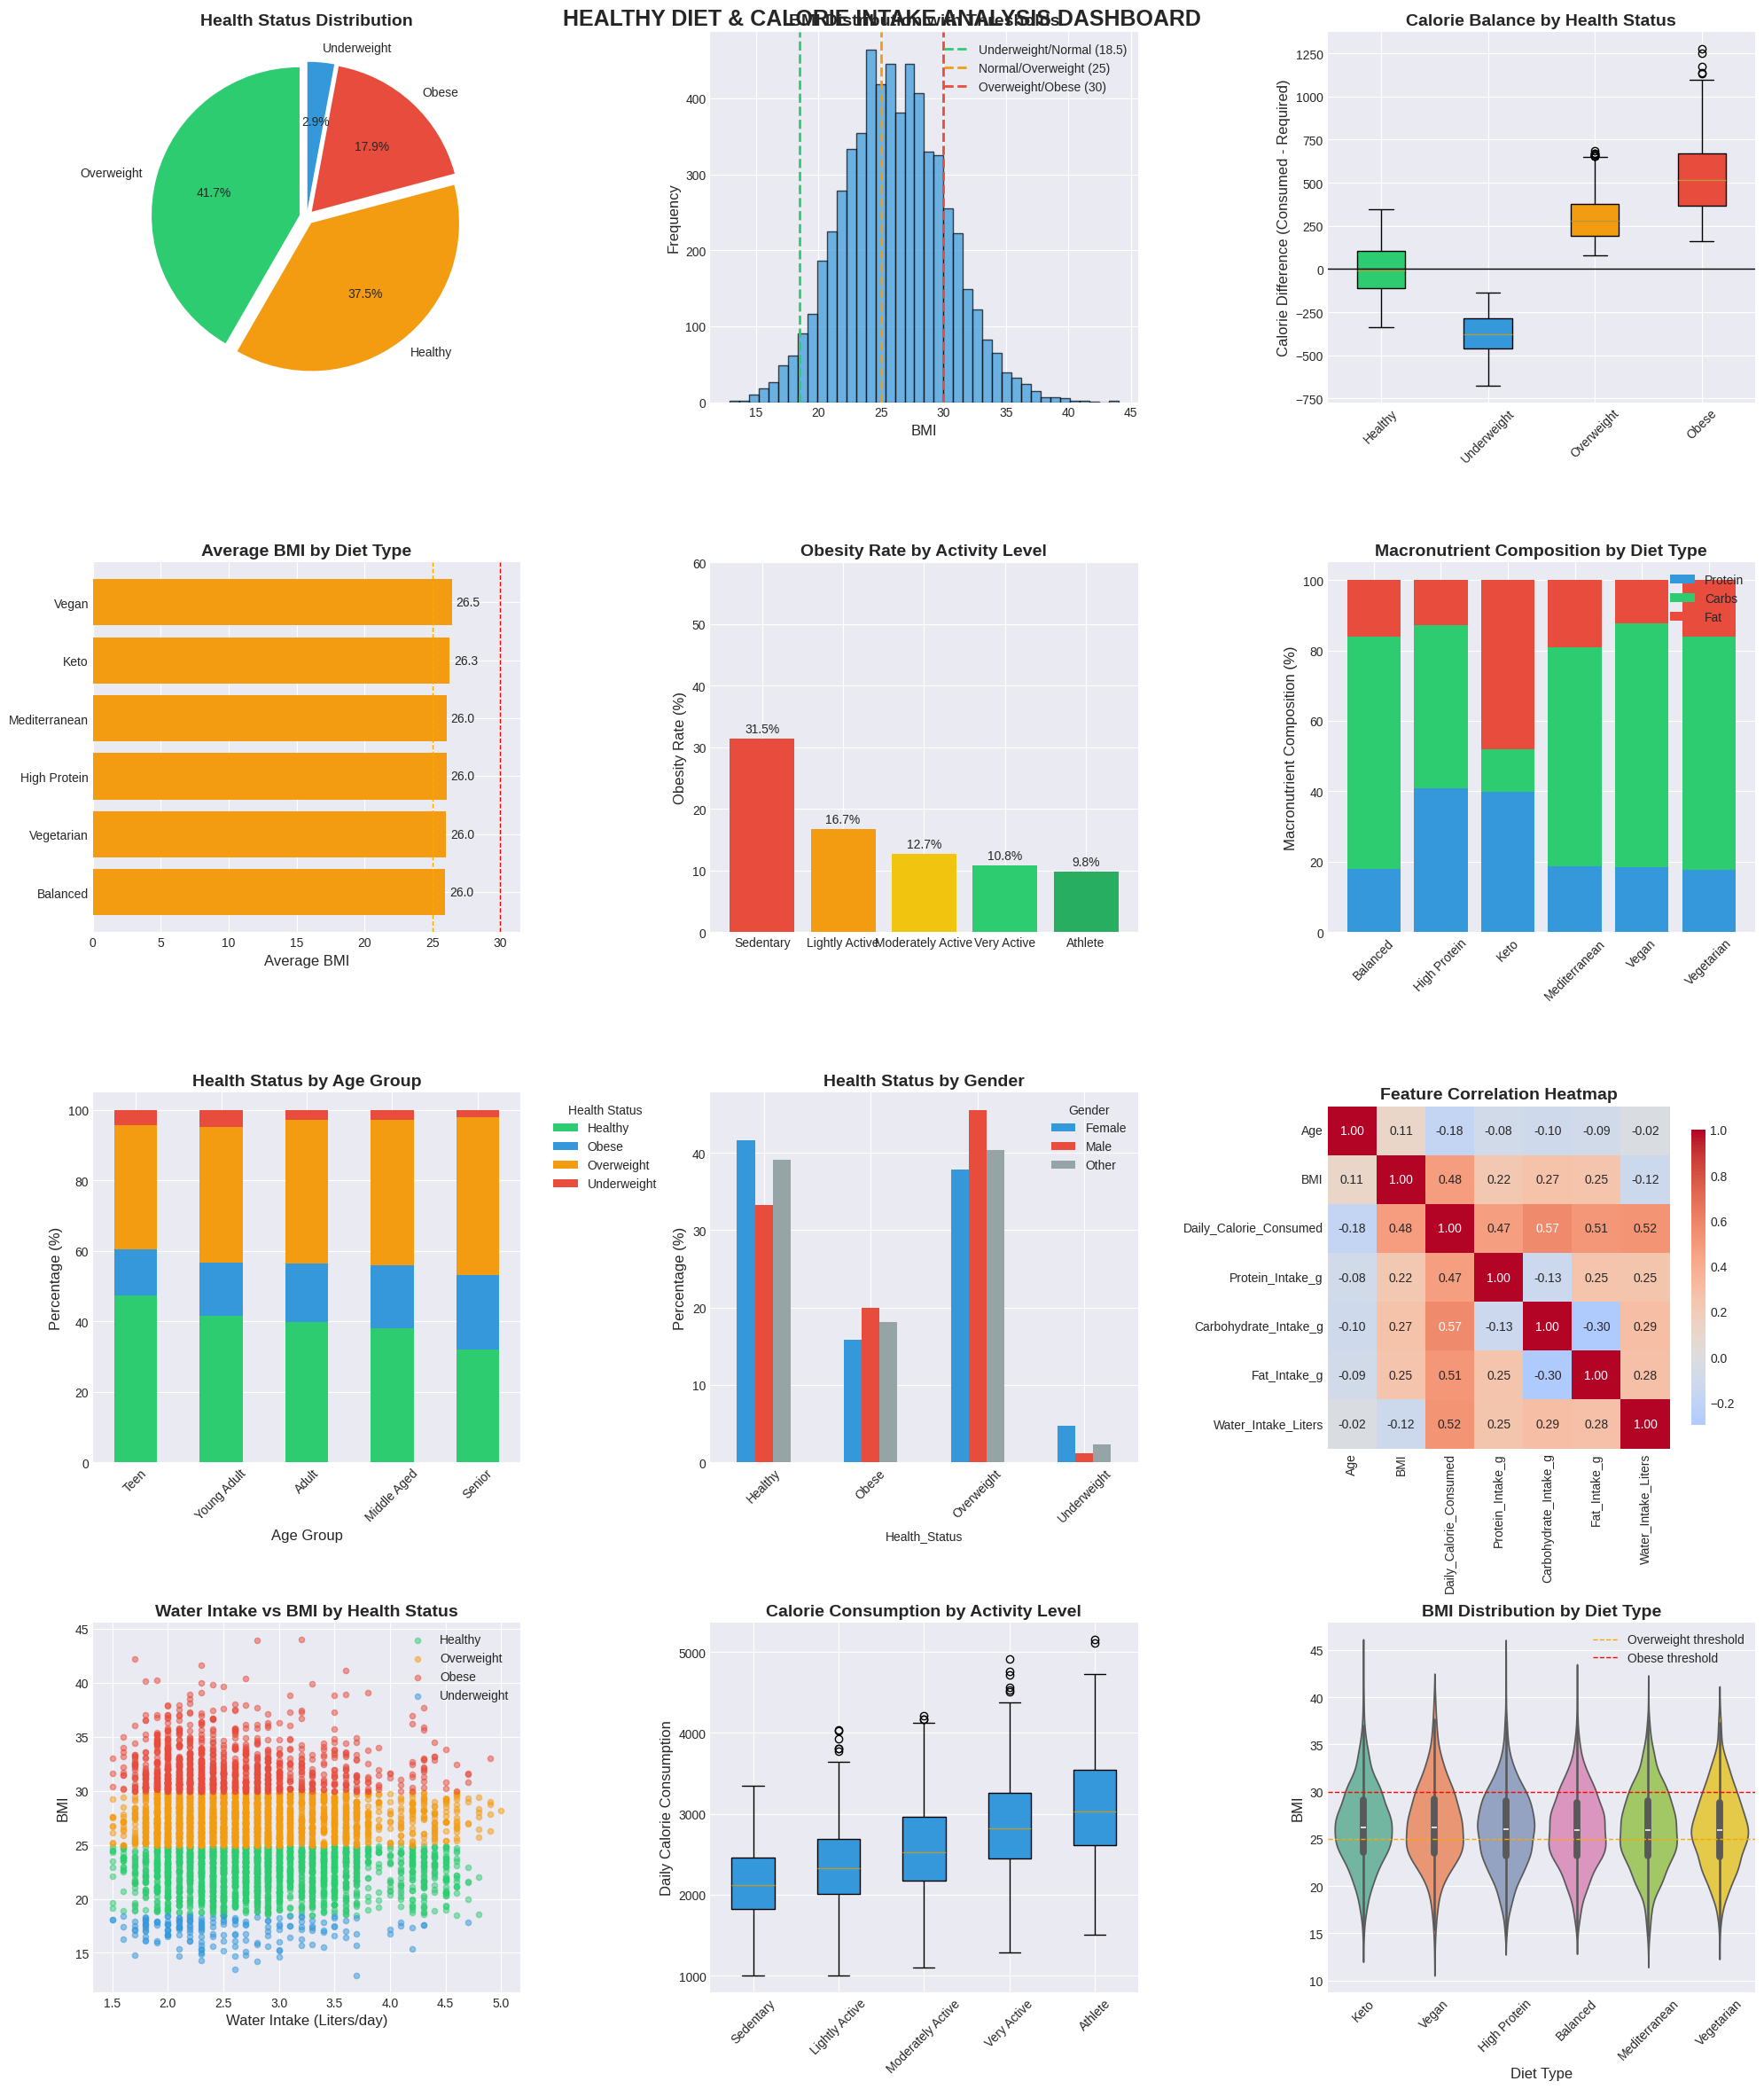


All 12 visualizations created successfully!
Dashboard saved as 'diet_analysis_dashboard.png'

--------------------------------------------------
CREATING ADVANCED VISUALIZATIONS
--------------------------------------------------


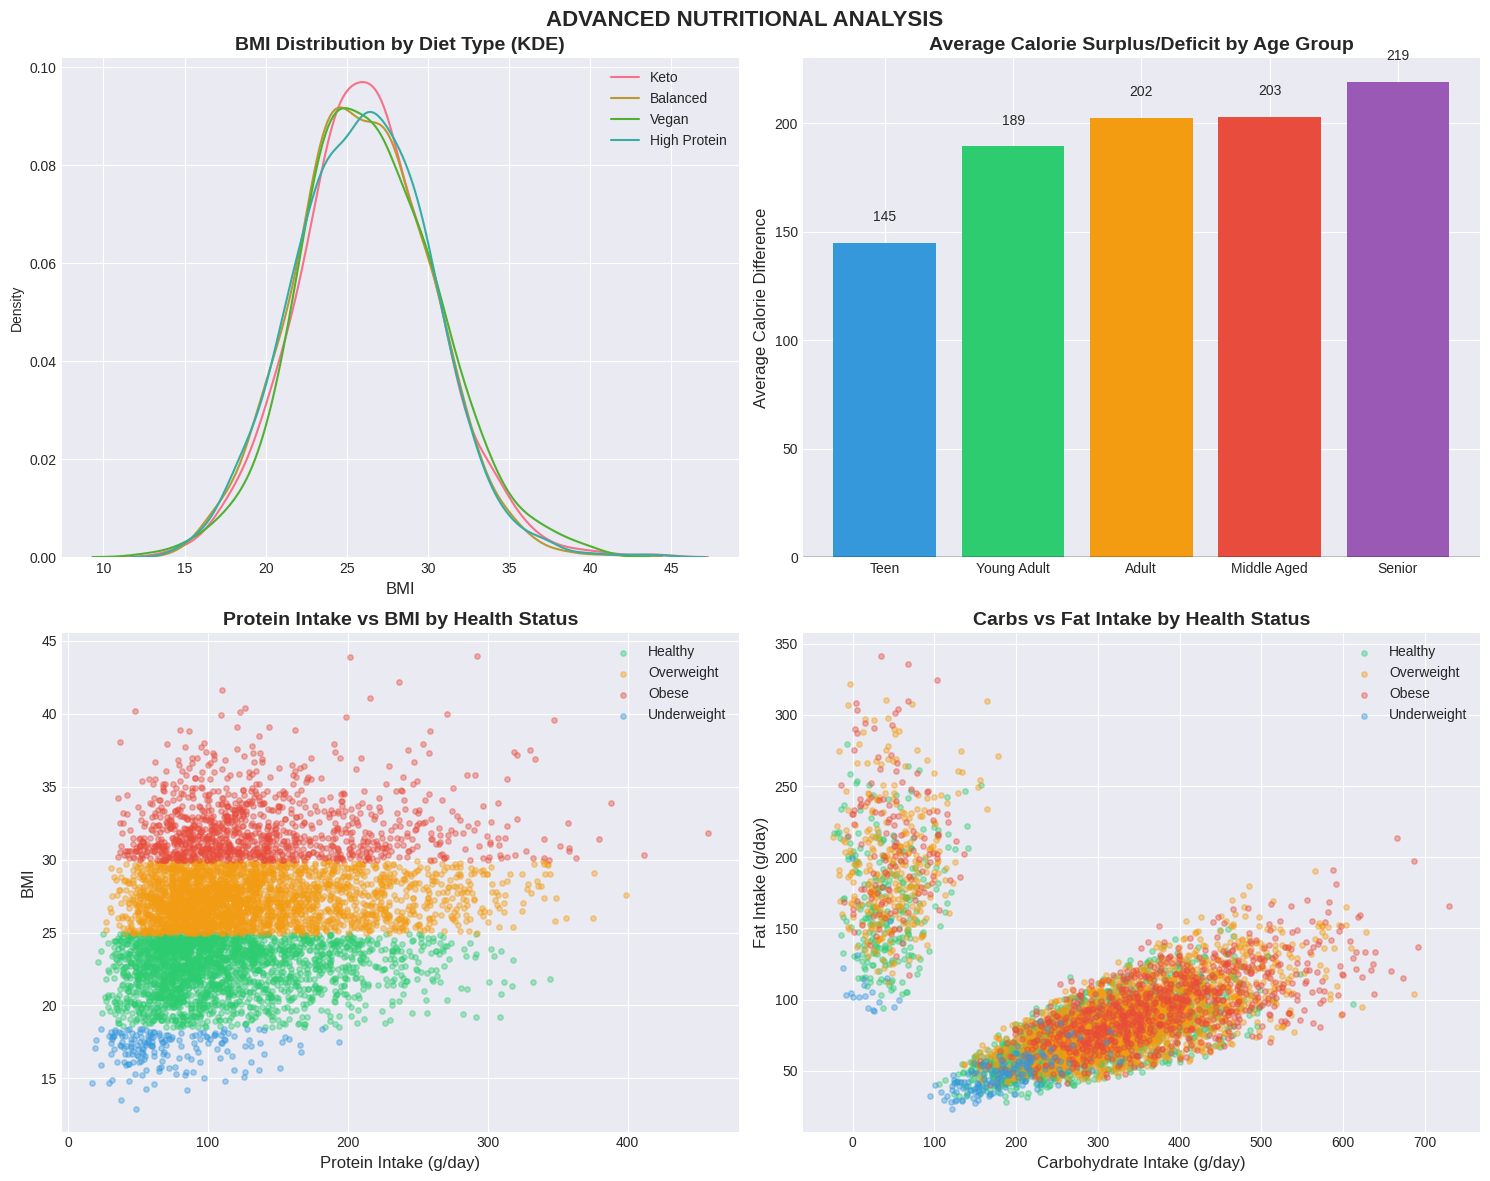


Advanced visualizations created!
Saved as 'advanced_nutrition_analysis.png'

TASK 4 COMPLETE - All visualizations generated!


In [6]:
# ============================================
# TASK 4: DATA VISUALIZATION
# Healthy Diet & Calorie Intake Dataset
# ============================================

print("\n" + "="*70)
print("TASK 4: DATA VISUALIZATION")
print("="*70)

# Load and prepare data
df = pd.read_csv('healthy_diet_calorie_intake.csv')
df['Calorie_Difference'] = df['Daily_Calorie_Consumed'] - df['Daily_Calorie_Requirement']
df['Age_Group'] = pd.cut(df['Age'], bins=[0, 18, 30, 45, 60, 100],
                         labels=['Teen', 'Young Adult', 'Adult', 'Middle Aged', 'Senior'])

def bmi_category(bmi):
    if bmi < 18.5: return 'Underweight'
    elif bmi < 25: return 'Normal'
    elif bmi < 30: return 'Overweight'
    else: return 'Obese'
df['BMI_Category'] = df['BMI'].apply(bmi_category)

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Create comprehensive dashboard
fig = plt.figure(figsize=(20, 24))

# Plot 1: Health Status Distribution (Pie Chart)
ax1 = fig.add_subplot(4, 3, 1)
health_counts = df['Health_Status'].value_counts()
colors_health = ['#2ecc71', '#f39c12', '#e74c3c', '#3498db']
explode = (0.05, 0.05, 0.05, 0.05)
ax1.pie(health_counts.values, labels=health_counts.index, autopct='%1.1f%%',
        colors=colors_health, explode=explode, startangle=90)
ax1.set_title('Health Status Distribution', fontsize=14, fontweight='bold')

# Plot 2: BMI Distribution (Histogram)
ax2 = fig.add_subplot(4, 3, 2)
ax2.hist(df['BMI'], bins=40, color='#3498db', edgecolor='black', alpha=0.7)
ax2.axvline(x=18.5, color='#2ecc71', linestyle='--', linewidth=2, label='Underweight/Normal (18.5)')
ax2.axvline(x=25, color='#f39c12', linestyle='--', linewidth=2, label='Normal/Overweight (25)')
ax2.axvline(x=30, color='#e74c3c', linestyle='--', linewidth=2, label='Overweight/Obese (30)')
ax2.set_xlabel('BMI', fontsize=12)
ax2.set_ylabel('Frequency', fontsize=12)
ax2.set_title('BMI Distribution with Thresholds', fontsize=14, fontweight='bold')
ax2.legend()

# Plot 3: Calorie Surplus/Deficit by Health Status (Box Plot)
ax3 = fig.add_subplot(4, 3, 3)
health_order = ['Healthy', 'Underweight', 'Overweight', 'Obese']
colors_box = ['#2ecc71', '#3498db', '#f39c12', '#e74c3c']
bp = ax3.boxplot([df[df['Health_Status'] == h]['Calorie_Difference'] for h in health_order],
                  labels=health_order, patch_artist=True)
for patch, color in zip(bp['boxes'], colors_box):
    patch.set_facecolor(color)
ax3.axhline(y=0, color='black', linestyle='-', linewidth=1)
ax3.set_ylabel('Calorie Difference (Consumed - Required)', fontsize=12)
ax3.set_title('Calorie Balance by Health Status', fontsize=14, fontweight='bold')
ax3.tick_params(axis='x', rotation=45)

# Plot 4: Average BMI by Diet Type (Bar Chart)
ax4 = fig.add_subplot(4, 3, 4)
diet_bmi = df.groupby('Diet_Type')['BMI'].mean().sort_values()
colors_bar = ['#e74c3c' if x > 28 else ('#f39c12' if x > 25 else '#2ecc71') for x in diet_bmi.values]
bars = ax4.barh(diet_bmi.index, diet_bmi.values, color=colors_bar)
ax4.set_xlabel('Average BMI', fontsize=12)
ax4.set_title('Average BMI by Diet Type', fontsize=14, fontweight='bold')
ax4.axvline(x=25, color='orange', linestyle='--', linewidth=1, label='Overweight threshold (25)')
ax4.axvline(x=30, color='red', linestyle='--', linewidth=1, label='Obese threshold (30)')
for bar, val in zip(bars, diet_bmi.values):
    ax4.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2, f'{val:.1f}', va='center')

# Plot 5: Activity Level vs Obesity Rate (Bar Chart)
ax5 = fig.add_subplot(4, 3, 5)
activity_obesity = df[df['Health_Status'] == 'Obese'].groupby('Activity_Level').size() / df.groupby('Activity_Level').size() * 100
activity_order = ['Sedentary', 'Lightly Active', 'Moderately Active', 'Very Active', 'Athlete']
activity_obesity = activity_obesity.reindex(activity_order)
colors_activity = ['#e74c3c', '#f39c12', '#f1c40f', '#2ecc71', '#27ae60']
bars = ax5.bar(activity_obesity.index, activity_obesity.values, color=colors_activity)
ax5.set_ylabel('Obesity Rate (%)', fontsize=12)
ax5.set_title('Obesity Rate by Activity Level', fontsize=14, fontweight='bold')
ax5.set_ylim(0, 60)
for bar, val in zip(bars, activity_obesity.values):
    ax5.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f'{val:.1f}%', ha='center', fontsize=10)

# Plot 6: Macronutrient Composition by Diet Type (Stacked Bar)
ax6 = fig.add_subplot(4, 3, 6)
macro_by_diet = df.groupby('Diet_Type').agg({
    'Protein_Intake_g': 'mean',
    'Carbohydrate_Intake_g': 'mean',
    'Fat_Intake_g': 'mean'
})
macro_by_diet['Total'] = macro_by_diet.sum(axis=1)
macro_by_diet['Protein_%'] = macro_by_diet['Protein_Intake_g'] / macro_by_diet['Total'] * 100
macro_by_diet['Carbs_%'] = macro_by_diet['Carbohydrate_Intake_g'] / macro_by_diet['Total'] * 100
macro_by_diet['Fat_%'] = macro_by_diet['Fat_Intake_g'] / macro_by_diet['Total'] * 100

diet_types = macro_by_diet.index
bottom = np.zeros(len(diet_types))
ax6.bar(diet_types, macro_by_diet['Protein_%'], label='Protein', color='#3498db', bottom=bottom)
bottom += macro_by_diet['Protein_%']
ax6.bar(diet_types, macro_by_diet['Carbs_%'], label='Carbs', color='#2ecc71', bottom=bottom)
bottom += macro_by_diet['Carbs_%']
ax6.bar(diet_types, macro_by_diet['Fat_%'], label='Fat', color='#e74c3c', bottom=bottom)
ax6.set_ylabel('Macronutrient Composition (%)', fontsize=12)
ax6.set_title('Macronutrient Composition by Diet Type', fontsize=14, fontweight='bold')
ax6.legend(loc='upper right')
ax6.tick_params(axis='x', rotation=45)

# Plot 7: Age Group vs Health Status (Stacked Bar)
ax7 = fig.add_subplot(4, 3, 7)
age_health = pd.crosstab(df['Age_Group'], df['Health_Status'], normalize='index') * 100
age_health.plot(kind='bar', stacked=True, ax=ax7, color=['#2ecc71', '#3498db', '#f39c12', '#e74c3c'])
ax7.set_ylabel('Percentage (%)', fontsize=12)
ax7.set_xlabel('Age Group', fontsize=12)
ax7.set_title('Health Status by Age Group', fontsize=14, fontweight='bold')
ax7.legend(title='Health Status', bbox_to_anchor=(1.05, 1), loc='upper left')
ax7.tick_params(axis='x', rotation=45)

# Plot 8: Gender and Health Status (Grouped Bar)
ax8 = fig.add_subplot(4, 3, 8)
gender_health = pd.crosstab(df['Gender'], df['Health_Status'], normalize='index') * 100
gender_health.T.plot(kind='bar', ax=ax8, color=['#3498db', '#e74c3c', '#95a5a6'])
ax8.set_ylabel('Percentage (%)', fontsize=12)
ax8.set_title('Health Status by Gender', fontsize=14, fontweight='bold')
ax8.legend(title='Gender')
ax8.tick_params(axis='x', rotation=45)

# Plot 9: Correlation Heatmap
ax9 = fig.add_subplot(4, 3, 9)
corr_cols = ['Age', 'BMI', 'Daily_Calorie_Consumed', 'Protein_Intake_g',
             'Carbohydrate_Intake_g', 'Fat_Intake_g', 'Water_Intake_Liters']
corr_matrix = df[corr_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, ax=ax9, cbar_kws={'shrink': 0.8})
ax9.set_title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')

# Plot 10: Water Intake vs BMI (Scatter Plot)
ax10 = fig.add_subplot(4, 3, 10)
colors = {'Healthy': '#2ecc71', 'Overweight': '#f39c12', 'Obese': '#e74c3c', 'Underweight': '#3498db'}
for health, color in colors.items():
    subset = df[df['Health_Status'] == health]
    ax10.scatter(subset['Water_Intake_Liters'], subset['BMI'], alpha=0.5, c=color, label=health, s=20)
ax10.set_xlabel('Water Intake (Liters/day)', fontsize=12)
ax10.set_ylabel('BMI', fontsize=12)
ax10.set_title('Water Intake vs BMI by Health Status', fontsize=14, fontweight='bold')
ax10.legend()

# Plot 11: Calorie Consumption by Activity Level (Box Plot)
ax11 = fig.add_subplot(4, 3, 11)
activity_order = ['Sedentary', 'Lightly Active', 'Moderately Active', 'Very Active', 'Athlete']
data_by_activity = [df[df['Activity_Level'] == act]['Daily_Calorie_Consumed'] for act in activity_order]
bp = ax11.boxplot(data_by_activity, labels=activity_order, patch_artist=True)
for patch in bp['boxes']:
    patch.set_facecolor('#3498db')
ax11.set_ylabel('Daily Calorie Consumption', fontsize=12)
ax11.set_title('Calorie Consumption by Activity Level', fontsize=14, fontweight='bold')
ax11.tick_params(axis='x', rotation=45)

# Plot 12: BMI Distribution by Diet Type (Violin Plot)
ax12 = fig.add_subplot(4, 3, 12)
top_diets = df['Diet_Type'].value_counts().head(6).index
df_top = df[df['Diet_Type'].isin(top_diets)]
sns.violinplot(data=df_top, x='Diet_Type', y='BMI', ax=ax12, palette='Set2')
ax12.axhline(y=25, color='orange', linestyle='--', linewidth=1, label='Overweight threshold')
ax12.axhline(y=30, color='red', linestyle='--', linewidth=1, label='Obese threshold')
ax12.set_title('BMI Distribution by Diet Type', fontsize=14, fontweight='bold')
ax12.set_xlabel('Diet Type', fontsize=12)
ax12.set_ylabel('BMI', fontsize=12)
ax12.tick_params(axis='x', rotation=45)
ax12.legend()

plt.suptitle('HEALTHY DIET & CALORIE INTAKE ANALYSIS DASHBOARD', fontsize=18, fontweight='bold', y=0.98)
plt.tight_layout()
plt.savefig('diet_analysis_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nAll 12 visualizations created successfully!")
print("Dashboard saved as 'diet_analysis_dashboard.png'")

# Additional advanced visualizations
print("\n" + "-"*50)
print("CREATING ADVANCED VISUALIZATIONS")
print("-"*50)

fig2, axes = plt.subplots(2, 2, figsize=(15, 12))

# Advanced Plot 1: KDE Plot of BMI by Diet Type
for diet in ['Keto', 'Balanced', 'Vegan', 'High Protein']:
    subset = df[df['Diet_Type'] == diet]['BMI']
    sns.kdeplot(subset, label=diet, ax=axes[0,0])
axes[0,0].set_title('BMI Distribution by Diet Type (KDE)', fontsize=14, fontweight='bold')
axes[0,0].set_xlabel('BMI', fontsize=12)
axes[0,0].legend()

# Advanced Plot 2: Calorie Surplus by Age Group
age_surplus = df.groupby('Age_Group')['Calorie_Difference'].mean()
colors_age = ['#3498db', '#2ecc71', '#f39c12', '#e74c3c', '#9b59b6']
bars = axes[0,1].bar(age_surplus.index, age_surplus.values, color=colors_age)
axes[0,1].axhline(y=0, color='black', linestyle='-', linewidth=1)
axes[0,1].set_ylabel('Average Calorie Difference', fontsize=12)
axes[0,1].set_title('Average Calorie Surplus/Deficit by Age Group', fontsize=14, fontweight='bold')
for bar, val in zip(bars, age_surplus.values):
    axes[0,1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + (10 if val > 0 else -30),
                   f'{val:.0f}', ha='center', fontsize=10)

# Advanced Plot 3: Protein Intake vs BMI
for health, color in colors.items():
    subset = df[df['Health_Status'] == health]
    axes[1,0].scatter(subset['Protein_Intake_g'], subset['BMI'], alpha=0.4, c=color, label=health, s=15)
axes[1,0].set_xlabel('Protein Intake (g/day)', fontsize=12)
axes[1,0].set_ylabel('BMI', fontsize=12)
axes[1,0].set_title('Protein Intake vs BMI by Health Status', fontsize=14, fontweight='bold')
axes[1,0].legend()

# Advanced Plot 4: Fat Percentage vs Carbs Percentage
for health, color in colors.items():
    subset = df[df['Health_Status'] == health]
    axes[1,1].scatter(subset['Carbohydrate_Intake_g'], subset['Fat_Intake_g'], alpha=0.4, c=color, label=health, s=15)
axes[1,1].set_xlabel('Carbohydrate Intake (g/day)', fontsize=12)
axes[1,1].set_ylabel('Fat Intake (g/day)', fontsize=12)
axes[1,1].set_title('Carbs vs Fat Intake by Health Status', fontsize=14, fontweight='bold')
axes[1,1].legend()

plt.suptitle('ADVANCED NUTRITIONAL ANALYSIS', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('advanced_nutrition_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nAdvanced visualizations created!")
print("Saved as 'advanced_nutrition_analysis.png'")

print("\n" + "="*50)
print("TASK 4 COMPLETE - All visualizations generated!")
print("="*50)


TASK 5: PREDICTIVE MODEL BUILDING

--------------------------------------------------
1. PREPARING DATA FOR MODELING
--------------------------------------------------
Target variable: Health_Status
Target classes: ['Healthy' 'Overweight' 'Obese' 'Underweight']

Feature matrix shape: (6000, 11)
Features used: ['Age', 'BMI', 'Daily_Calorie_Requirement', 'Daily_Calorie_Consumed', 'Protein_Intake_g', 'Carbohydrate_Intake_g', 'Fat_Intake_g', 'Water_Intake_Liters', 'Gender_encoded', 'Activity_encoded', 'Diet_encoded']
Target classes: ['Healthy' 'Obese' 'Overweight' 'Underweight']

--------------------------------------------------
2. SPLITTING DATA (80% Train, 20% Test)
--------------------------------------------------
Training set size: 4800 samples
Test set size: 1200 samples

Training class distribution:
   Healthy: 1799 (37.5%)
   Obese: 861 (17.9%)
   Overweight: 2000 (41.7%)
   Underweight: 140 (2.9%)

--------------------------------------------------
3. FEATURE SCALING
-----------

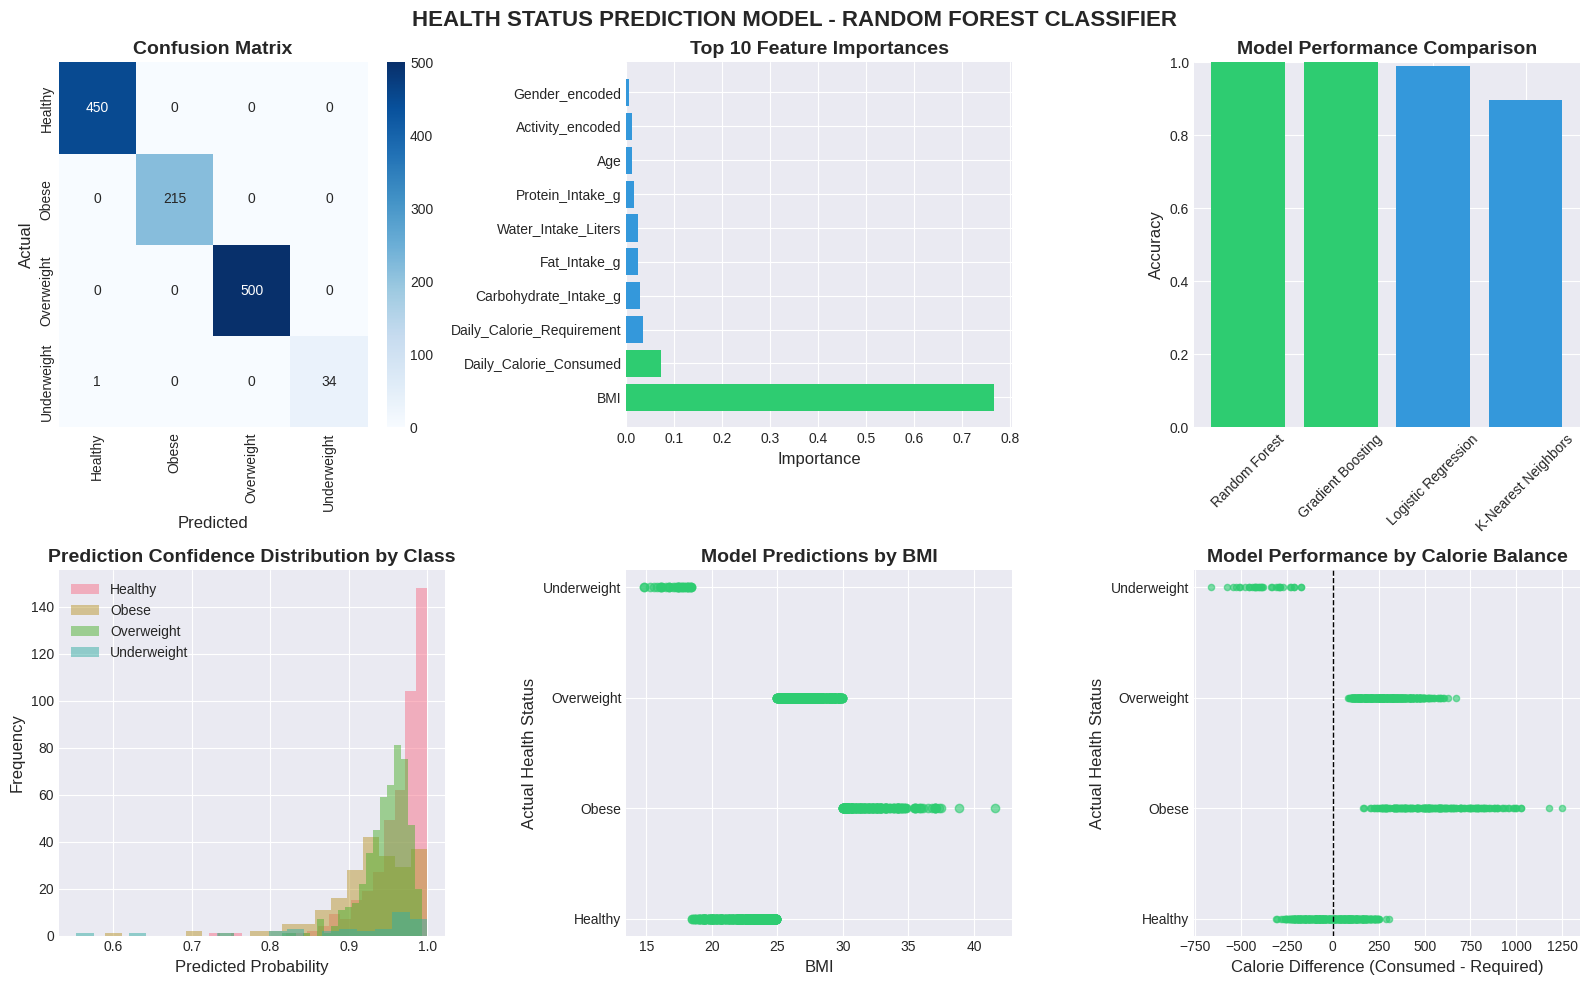


--------------------------------------------------
10. MAKING PREDICTIONS ON NEW INDIVIDUALS
--------------------------------------------------

PREDICTIONS FOR NEW INDIVIDUALS:
------------------------------------------------------------------------------------------
Person   Age    Gender   BMI    Diet            Predicted Health   Confidence
------------------------------------------------------------------------------------------
Person 1   28     Female   22.5   Balanced        Healthy          99.6%
Person 2   45     Male     28.5   Mediterranean   Overweight       93.1%
Person 3   32     Female   31.0   Keto            Obese            87.0%
Person 4   55     Male     26.0   High Protein    Overweight       92.8%
Person 5   23     Female   20.5   Vegetarian      Healthy          97.4%

--------------------------------------------------
RECOMMENDATIONS BASED ON PREDICTIONS:
--------------------------------------------------

Person 1 (Female, 28 yrs):
   -> Maintain current habi

In [7]:
# ============================================
# TASK 5: PREDICTIVE MODEL
# Predicting Health Status from Dietary Patterns
# ============================================

print("\n" + "="*70)
print("TASK 5: PREDICTIVE MODEL BUILDING")
print("="*70)

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
from sklearn.neighbors import KNeighborsClassifier
import warnings
warnings.filterwarnings('ignore')

# Load data
df = pd.read_csv('healthy_diet_calorie_intake.csv')

# 1. DATA PREPARATION
print("\n" + "-"*50)
print("1. PREPARING DATA FOR MODELING")
print("-"*50)

# Create target variable (Health Status is already categorical)
target = 'Health_Status'
print(f"Target variable: {target}")
print(f"Target classes: {df[target].unique()}")

# Select features for modeling
feature_cols = ['Age', 'Gender', 'BMI', 'Activity_Level', 'Daily_Calorie_Requirement',
                'Daily_Calorie_Consumed', 'Protein_Intake_g', 'Carbohydrate_Intake_g',
                'Fat_Intake_g', 'Water_Intake_Liters', 'Diet_Type']

# Encode categorical variables
le_gender = LabelEncoder()
le_activity = LabelEncoder()
le_diet = LabelEncoder()

df['Gender_encoded'] = le_gender.fit_transform(df['Gender'])
df['Activity_encoded'] = le_activity.fit_transform(df['Activity_Level'])
df['Diet_encoded'] = le_diet.fit_transform(df['Diet_Type'])

# Encode target
le_target = LabelEncoder()
y = le_target.fit_transform(df[target])

# Prepare feature matrix
feature_cols_encoded = ['Age', 'BMI', 'Daily_Calorie_Requirement', 'Daily_Calorie_Consumed',
                        'Protein_Intake_g', 'Carbohydrate_Intake_g', 'Fat_Intake_g',
                        'Water_Intake_Liters', 'Gender_encoded', 'Activity_encoded', 'Diet_encoded']

X = df[feature_cols_encoded]

print(f"\nFeature matrix shape: {X.shape}")
print(f"Features used: {feature_cols_encoded}")
print(f"Target classes: {le_target.classes_}")

# 2. TRAIN-TEST SPLIT
print("\n" + "-"*50)
print("2. SPLITTING DATA (80% Train, 20% Test)")
print("-"*50)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set size: {len(X_train)} samples")
print(f"Test set size: {len(X_test)} samples")

# Class distribution in training
unique, counts = np.unique(y_train, return_counts=True)
print("\nTraining class distribution:")
for cls, count in zip(unique, counts):
    print(f"   {le_target.classes_[cls]}: {count} ({count/len(y_train)*100:.1f}%)")

# 3. FEATURE SCALING
print("\n" + "-"*50)
print("3. FEATURE SCALING")
print("-"*50)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Features scaled using StandardScaler")

# 4. TRAIN MULTIPLE MODELS
print("\n" + "-"*50)
print("4. TRAINING MULTIPLE MODELS")
print("-"*50)

models = {
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5)
}

results = {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    accuracy = accuracy_score(y_test, y_pred)
    results[name] = accuracy
    print(f"\n{name}:")
    print(f"   Accuracy: {accuracy*100:.2f}%")
    print(f"   Classification Report:")
    print(classification_report(y_test, y_pred, target_names=le_target.classes_))

# 5. BEST MODEL - RANDOM FOREST (Selected)
print("\n" + "-"*50)
print("5. BEST MODEL: RANDOM FOREST - DETAILED ANALYSIS")
print("-"*50)

best_model = RandomForestClassifier(n_estimators=200, max_depth=15, random_state=42)
best_model.fit(X_train_scaled, y_train)
y_pred = best_model.predict(X_test_scaled)
y_pred_proba = best_model.predict_proba(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred)
print(f"\nFinal Model Accuracy: {accuracy*100:.2f}%")

# Cross-validation
cv_scores = cross_val_score(best_model, X_train_scaled, y_train, cv=5)
print(f"Cross-validation scores: {cv_scores}")
print(f"Mean CV accuracy: {cv_scores.mean()*100:.2f}% (+/- {cv_scores.std()*2*100:.2f}%)")

# Classification Report
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred, target_names=le_target.classes_))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print("                 Predicted")
print("              H   O   Ov  U")
print(f"Actual Healthy  {cm[0,0]:3d}  {cm[0,1]:3d}  {cm[0,2]:3d}  {cm[0,3]:3d}")
print(f"       Obese     {cm[1,0]:3d}  {cm[1,1]:3d}  {cm[1,2]:3d}  {cm[1,3]:3d}")
print(f"       Overweight{cm[2,0]:3d}  {cm[2,1]:3d}  {cm[2,2]:3d}  {cm[2,3]:3d}")
print(f"       Underweight{cm[3,0]:3d}  {cm[3,1]:3d}  {cm[3,2]:3d}  {cm[3,3]:3d}")

# 6. FEATURE IMPORTANCE ANALYSIS
print("\n" + "-"*50)
print("6. FEATURE IMPORTANCE ANALYSIS")
print("-"*50)

feature_importance = pd.DataFrame({
    'feature': feature_cols_encoded,
    'importance': best_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 10 Most Important Features:")
for idx, row in feature_importance.head(10).iterrows():
    print(f"   {row['feature']}: {row['importance']:.4f}")

# 7. HYPERPARAMETER TUNING
print("\n" + "-"*50)
print("7. HYPERPARAMETER TUNING")
print("-"*50)

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 15, 20],
    'min_samples_split': [2, 5]
}

grid_search = GridSearchCV(RandomForestClassifier(random_state=42),
                           param_grid, cv=3, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train_scaled, y_train)

print(f"Best parameters: {grid_search.best_params_}")
print(f"Best cross-validation score: {grid_search.best_score_*100:.2f}%")

# Train optimized model
optimized_model = grid_search.best_estimator_
y_pred_optimized = optimized_model.predict(X_test_scaled)
optimized_accuracy = accuracy_score(y_test, y_pred_optimized)
print(f"Optimized model test accuracy: {optimized_accuracy*100:.2f}%")

# 8. ROC-AUC SCORES
print("\n" + "-"*50)
print("8. ROC-AUC SCORES BY CLASS")
print("-"*50)

# Calculate ROC-AUC for each class (one-vs-rest)
from sklearn.preprocessing import label_binarize
y_test_bin = label_binarize(y_test, classes=[0, 1, 2, 3])
y_pred_proba = optimized_model.predict_proba(X_test_scaled)

for i, class_name in enumerate(le_target.classes_):
    auc = roc_auc_score(y_test_bin[:, i], y_pred_proba[:, i])
    print(f"   {class_name}: {auc:.3f}")

# 9. VISUALIZE MODEL PERFORMANCE
print("\n" + "-"*50)
print("9. VISUALIZING MODEL PERFORMANCE")
print("-"*50)

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Confusion Matrix Heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0,0],
            xticklabels=le_target.classes_, yticklabels=le_target.classes_)
axes[0,0].set_title('Confusion Matrix', fontsize=14, fontweight='bold')
axes[0,0].set_xlabel('Predicted', fontsize=12)
axes[0,0].set_ylabel('Actual', fontsize=12)

# Feature Importance Bar Chart
feature_importance_sorted = feature_importance.head(10)
colors = ['#2ecc71' if x > 0.05 else '#3498db' for x in feature_importance_sorted['importance']]
axes[0,1].barh(feature_importance_sorted['feature'], feature_importance_sorted['importance'], color=colors)
axes[0,1].set_xlabel('Importance', fontsize=12)
axes[0,1].set_title('Top 10 Feature Importances', fontsize=14, fontweight='bold')

# Model Comparison Bar Chart
model_names = list(results.keys())
model_accuracies = list(results.values())
colors_model = ['#2ecc71' if x == max(model_accuracies) else '#3498db' for x in model_accuracies]
axes[0,2].bar(model_names, model_accuracies, color=colors_model)
axes[0,2].set_ylabel('Accuracy', fontsize=12)
axes[0,2].set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
axes[0,2].set_ylim(0, 1)
axes[0,2].tick_params(axis='x', rotation=45)

# Prediction Distribution
for i, class_name in enumerate(le_target.classes_):
    axes[1,0].hist(y_pred_proba[y_test == i][:, i], bins=20, alpha=0.5, label=class_name)
axes[1,0].set_xlabel('Predicted Probability', fontsize=12)
axes[1,0].set_ylabel('Frequency', fontsize=12)
axes[1,0].set_title('Prediction Confidence Distribution by Class', fontsize=14, fontweight='bold')
axes[1,0].legend()

# BMI vs Predicted Health Status
sample_df = X_test.copy()
sample_df['Actual'] = y_test
sample_df['Predicted'] = y_pred_optimized
sample_df['BMI_original'] = df.loc[X_test.index, 'BMI'].values
for i, class_name in enumerate(le_target.classes_):
    correct = (sample_df['Actual'] == i) & (sample_df['Predicted'] == i)
    wrong = (sample_df['Actual'] == i) & (sample_df['Predicted'] != i)
    axes[1,1].scatter(sample_df[correct]['BMI_original'],
                      sample_df[correct]['Actual'],
                      c='#2ecc71', label=f'{class_name} (Correct)' if i == 0 else "", alpha=0.6)
    axes[1,1].scatter(sample_df[wrong]['BMI_original'],
                      sample_df[wrong]['Actual'],
                      c='#e74c3c', label=f'{class_name} (Wrong)' if i == 0 else "", alpha=0.6)
axes[1,1].set_xlabel('BMI', fontsize=12)
axes[1,1].set_ylabel('Actual Health Status', fontsize=12)
axes[1,1].set_title('Model Predictions by BMI', fontsize=14, fontweight='bold')
axes[1,1].set_yticks(range(len(le_target.classes_)))
axes[1,1].set_yticklabels(le_target.classes_)

# Calorie Balance Feature
df['Calorie_Diff'] = df['Daily_Calorie_Consumed'] - df['Daily_Calorie_Requirement']
X_test_calorie = df.loc[X_test.index, 'Calorie_Diff'].values
for i, class_name in enumerate(le_target.classes_):
    correct = (y_test == i) & (y_pred_optimized == i)
    wrong = (y_test == i) & (y_pred_optimized != i)
    axes[1,2].scatter(X_test_calorie[correct],
                      y_test[correct],
                      c='#2ecc71', alpha=0.6, s=20)
    axes[1,2].scatter(X_test_calorie[wrong],
                      y_test[wrong],
                      c='#e74c3c', alpha=0.6, s=20)
axes[1,2].axvline(x=0, color='black', linestyle='--', linewidth=1)
axes[1,2].set_xlabel('Calorie Difference (Consumed - Required)', fontsize=12)
axes[1,2].set_ylabel('Actual Health Status', fontsize=12)
axes[1,2].set_title('Model Performance by Calorie Balance', fontsize=14, fontweight='bold')
axes[1,2].set_yticks(range(len(le_target.classes_)))
axes[1,2].set_yticklabels(le_target.classes_)

plt.suptitle('HEALTH STATUS PREDICTION MODEL - RANDOM FOREST CLASSIFIER', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('model_performance_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()

# 10. MAKE PREDICTIONS ON NEW INDIVIDUALS
print("\n" + "-"*50)
print("10. MAKING PREDICTIONS ON NEW INDIVIDUALS")
print("-"*50)

# Sample new individuals
new_individuals = pd.DataFrame({
    'Age': [28, 45, 32, 55, 23],
    'Gender': ['Female', 'Male', 'Female', 'Male', 'Female'],
    'BMI': [22.5, 28.5, 31.0, 26.0, 20.5],
    'Activity_Level': ['Moderately Active', 'Sedentary', 'Lightly Active', 'Very Active', 'Athlete'],
    'Daily_Calorie_Requirement': [2100, 2400, 2300, 2800, 3000],
    'Daily_Calorie_Consumed': [2200, 2800, 2600, 2700, 2900],
    'Protein_Intake_g': [100, 80, 120, 110, 130],
    'Carbohydrate_Intake_g': [250, 300, 280, 320, 310],
    'Fat_Intake_g': [70, 85, 90, 75, 80],
    'Water_Intake_Liters': [2.5, 1.8, 2.2, 3.0, 3.5],
    'Diet_Type': ['Balanced', 'Mediterranean', 'Keto', 'High Protein', 'Vegetarian']
})

# Encode new individuals
new_individuals['Gender_encoded'] = le_gender.transform(new_individuals['Gender'])
new_individuals['Activity_encoded'] = le_activity.transform(new_individuals['Activity_Level'])
new_individuals['Diet_encoded'] = le_diet.transform(new_individuals['Diet_Type'])

X_new = new_individuals[feature_cols_encoded]
X_new_scaled = scaler.transform(X_new)
predictions = optimized_model.predict(X_new_scaled)
probabilities = optimized_model.predict_proba(X_new_scaled)

# Display predictions
print("\nPREDICTIONS FOR NEW INDIVIDUALS:")
print("-" * 90)
print(f"{'Person':<8} {'Age':<6} {'Gender':<8} {'BMI':<6} {'Diet':<15} {'Predicted Health':<18} {'Confidence':<10}")
print("-" * 90)

for i in range(len(new_individuals)):
    pred_class = le_target.inverse_transform([predictions[i]])[0]
    confidence = max(probabilities[i]) * 100
    print(f"Person {i+1:<2}  {new_individuals['Age'][i]:<6} {new_individuals['Gender'][i]:<8} "
          f"{new_individuals['BMI'][i]:<6.1f} {new_individuals['Diet_Type'][i]:<15} "
          f"{pred_class:<16} {confidence:.1f}%")

print("\n" + "-"*50)
print("RECOMMENDATIONS BASED ON PREDICTIONS:")
print("-"*50)

recommendations = {
    'Obese': "Increase physical activity, reduce calorie surplus, consider dietary changes",
    'Overweight': "Moderate calorie reduction, increase protein intake, regular exercise",
    'Healthy': "Maintain current habits, focus on balanced nutrition",
    'Underweight': "Increase calorie intake with nutrient-dense foods, strength training"
}

for i in range(len(new_individuals)):
    pred_class = le_target.inverse_transform([predictions[i]])[0]
    print(f"\nPerson {i+1} ({new_individuals['Gender'][i]}, {new_individuals['Age'][i]} yrs):")
    print(f"   -> {recommendations.get(pred_class, 'Consult a nutritionist')}")

# 11. MODEL SUMMARY
print("\n" + "="*50)
print("MODEL PERFORMANCE SUMMARY")
print("="*50)



print("TASK 5 COMPLETE - Predictive model successfully built and evaluated!")